# 03 -- Window Bucketing (evolving causal graphs)

Rakesh's experiment. Consumes the **causal-ready** data from `02_causal_prep` and simply **slices** it into overlapping windows -- no re-processing (02 already imputed / smoothed / detrended / standardized).

**Guarantees:** windows are cut **within each segment only**, so none straddle the 233-day gap. Overlap within a segment is the sliding stride.

**Resolution:** the causal-ready data is 5-min, so `WINDOW=10000` ~ 35 days and `STRIDE=5000` ~ 17 days (Rakesh's spec). Each window CSV is one LiNGAM input; running LiNGAM on the sequence shows the causal structure evolve over time.

In [1]:
import os

# -- CHANGE THESE -------------------------------------------------------------
INPUT_DIR  = r"C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\causal_ready"   # 02 output
OUTPUT_DIR = r"C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\windows"

WINDOW  = 10000   # rows per window (5-min ~ 34.7 days)
STRIDE  = 5000    # step between windows (5-min ~ 17.4 days)
MIN_ROWS = 5000   # discard a trailing window shorter than this

RESTANDARDIZE_PER_WINDOW = False   # 02 already standardized per segment; set True to re-standardize each window
TURBINES = None                    # None = all; or e.g. ['wt84']
# -----------------------------------------------------------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)
files = {os.path.splitext(f)[0].replace('_causal_ready',''): os.path.join(INPUT_DIR,f)
         for f in sorted(os.listdir(INPUT_DIR)) if f.endswith('_causal_ready.csv')} if os.path.isdir(INPUT_DIR) else {}
if TURBINES: files = {k:v for k,v in files.items() if k in TURBINES}
print('Input :', INPUT_DIR)
print('Output:', OUTPUT_DIR)
print('Window/stride/min:', WINDOW, '/', STRIDE, '/', MIN_ROWS)
for k,v in files.items(): print('  ', k, '->', 'OK' if os.path.exists(v) else 'MISSING')
if not files: print('\n[!] No *_causal_ready.csv found -- run 02_causal_prep first.')

Input : C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\causal_ready
Output: C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\windows
Window/stride/min: 10000 / 5000 / 5000
   wt80 -> OK
   wt81 -> OK
   wt82 -> OK
   wt83 -> OK
   wt84 -> OK


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':100,'font.size':9,'axes.grid':True,'grid.alpha':0.3})
print('Imports OK')

Imports OK


## 1 -- Load causal-ready data

In [3]:
ready = {}
for label,path in files.items():
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = 'timestamp'
    if 'segment_id' not in df.columns: df['segment_id'] = 0
    ready[label] = df
    print(f'{label}: {len(df):,} rows | {df["segment_id"].nunique()} segment(s)')
FEATURES = [c for c in next(iter(ready.values())).columns if c != 'segment_id']
print('\nFeatures:', FEATURES)

wt80: 241,718 rows | 2 segment(s)
wt81: 243,849 rows | 2 segment(s)
wt82: 241,707 rows | 2 segment(s)
wt83: 241,719 rows | 2 segment(s)
wt84: 241,707 rows | 2 segment(s)

Features: ['wrot_avg_A_ValBl1', 'wrot_avg_A_ValBl2', 'wrot_avg_V_ValBl1', 'wrot_min_TmpPwrSply_ValBl1', 'wrot_min_A_ValBl1', 'wrot_max_A_ValBl2', 'wrot_sdv_TmpHtSinkPco_Bl1']


## 2 -- Generate windows (within each segment)

Windows are cut by row position inside each segment. The feasibility print flags any segment too short for one window.

In [4]:
def make_windows(L,W,S,min_rows):
    wins,start=[],0
    while start<L:
        end=min(start+W,L)
        if end-start>=min_rows: wins.append((start,end))
        if end==L: break
        start+=S
    return wins

manifest=[]
for label, df in ready.items():
    for sid,g in df.groupby('segment_id'):
        g=g.sort_index(); L=len(g)
        wins=make_windows(L,WINDOW,STRIDE,MIN_ROWS)
        if not wins:
            print(f'[!] {label} seg{sid}: {L} rows -- too short for WINDOW={WINDOW} (0 windows)')
        for wi,(a,b) in enumerate(wins):
            sub=g.iloc[a:b]
            manifest.append({'turbine':label,'segment_id':int(sid),'window_id':wi,
                             'row_start':a,'row_end':b,'n_rows':b-a,
                             't_start':sub.index.min(),'t_end':sub.index.max()})
manifest=pd.DataFrame(manifest)
if len(manifest):
    print('Windows per turbine:'); print(manifest.groupby('turbine').size().to_string())
    print('\nTotal windows:', len(manifest), '\n')
    print(manifest.head(10).to_string(index=False))
else:
    print('No windows generated -- reduce WINDOW or check 02 output.')

Windows per turbine:
turbine
wt80    48
wt81    48
wt82    48
wt83    48
wt84    48

Total windows: 240 

turbine  segment_id  window_id  row_start  row_end  n_rows             t_start               t_end
   wt80           0          0          0    10000   10000 2012-01-01 01:05:00 2012-02-04 18:20:00
   wt80           0          1       5000    15000   10000 2012-01-18 09:45:00 2012-02-22 03:00:00
   wt80           0          2      10000    20000   10000 2012-02-04 18:25:00 2012-03-10 11:40:00
   wt80           0          3      15000    25000   10000 2012-02-22 03:05:00 2012-03-27 20:20:00
   wt80           0          4      20000    30000   10000 2012-03-10 11:45:00 2012-04-14 05:00:00
   wt80           0          5      25000    35000   10000 2012-03-27 20:25:00 2012-05-01 13:40:00
   wt80           0          6      30000    40000   10000 2012-04-14 05:05:00 2012-05-18 22:20:00
   wt80           0          7      35000    45000   10000 2012-05-01 13:45:00 2012-06-05 07:00:00
   

## 3 -- Visualize the sliding windows

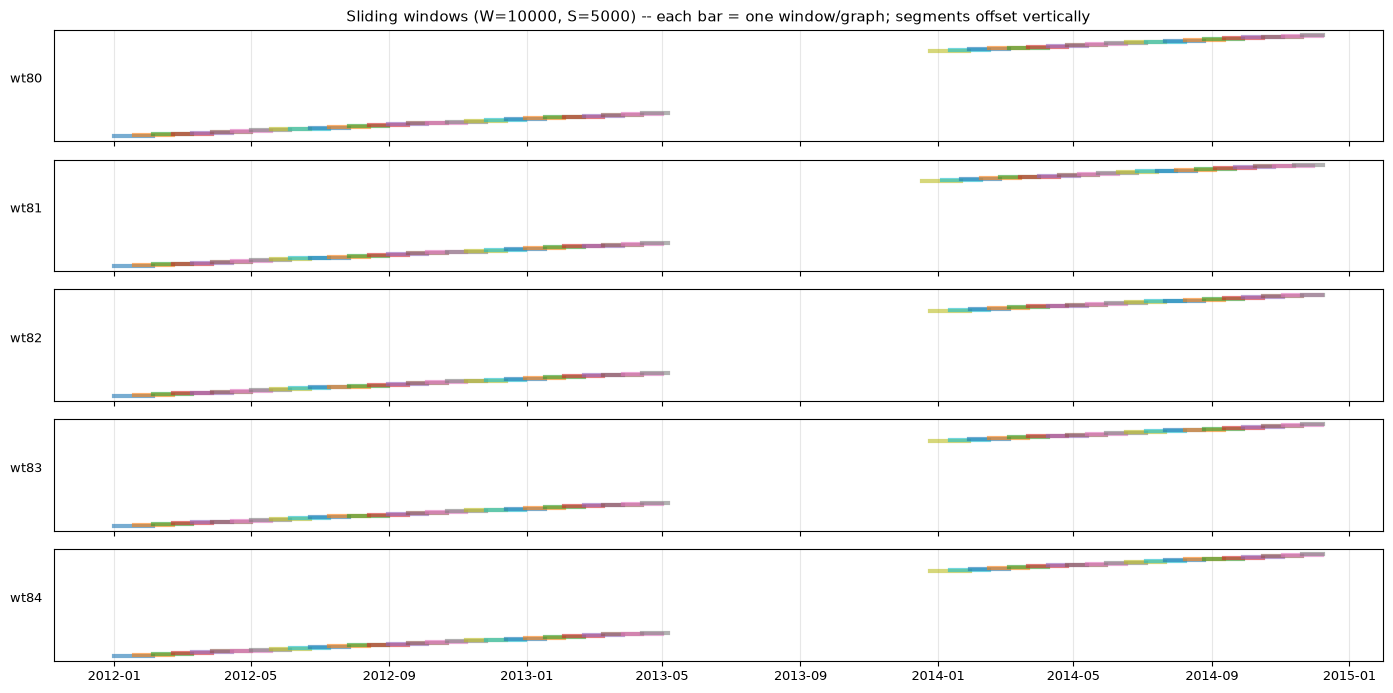

In [5]:
if len(manifest):
    labels=manifest['turbine'].unique()
    fig,axes=plt.subplots(len(labels),1,figsize=(14,1.4*len(labels)),sharex=True)
    if len(labels)==1: axes=[axes]
    for ax,label in zip(axes,labels):
        sub=manifest[manifest.turbine==label]
        for _,r in sub.iterrows():
            y=r['window_id']+r['segment_id']*100
            ax.plot([r['t_start'],r['t_end']],[y,y],lw=3,alpha=0.6)
        ax.set_ylabel(label,rotation=0,labelpad=20); ax.set_yticks([])
    axes[0].set_title(f'Sliding windows (W={WINDOW}, S={STRIDE}) -- each bar = one window/graph; segments offset vertically')
    plt.tight_layout(); plt.show()
else:
    print('Nothing to plot.')

## 4 -- Save one CSV per window

In [6]:
def standardize(df, cols):
    out=df.copy(); mu=out[cols].mean(); sd=out[cols].std().replace(0,1.0)
    out[cols]=(out[cols]-mu)/sd; return out

saved=[]
for _,r in manifest.iterrows():
    g=ready[r['turbine']]; g=g[g['segment_id']==r['segment_id']].sort_index()
    sub=g.iloc[r['row_start']:r['row_end']][FEATURES].copy()
    if RESTANDARDIZE_PER_WINDOW: sub=standardize(sub, FEATURES)
    fname=f"{r['turbine']}_seg{r['segment_id']}_win{r['window_id']:03d}.csv"
    path=os.path.join(OUTPUT_DIR,fname); sub.to_csv(path); saved.append(fname)

mout=manifest.copy(); mout['file']=saved
mout.to_csv(os.path.join(OUTPUT_DIR,'windows_manifest.csv'), index=False)
print(f'Saved {len(saved)} window CSVs + windows_manifest.csv to:'); print(' ', OUTPUT_DIR)

Saved 240 window CSVs + windows_manifest.csv to:
  C:\Eminds pros\E-minds projects\fuhrlander\causal-data-engine\pipeline\windows


## 5 -- (Template) Run LiNGAM per window

Requires `pip install lingam`. Loops the manifest and fits a model to each window; store/compare the adjacency matrices to see the structure evolve.

In [7]:
# import lingam
# graphs = {}
# for _, r in mout.iterrows():
#     sub = pd.read_csv(os.path.join(OUTPUT_DIR, r['file']), index_col=0)
#     model = lingam.DirectLiNGAM().fit(sub.values)
#     graphs[f"{r['turbine']}_seg{r['segment_id']}_win{r['window_id']:03d}"] = model.adjacency_matrix_
# # track one edge i->j across windows to watch it evolve
print('LiNGAM template -- uncomment once lingam is installed.')

LiNGAM template -- uncomment once lingam is installed.
